# Exploratory Data Analysis

Exploring the Sentinel-1 SAR imagery and hand-labeled flood masks used to train the flood detection U-Net.

Dataset: [Sen1Floods11](https://github.com/cloudtostreet/Sen1Floods11) (Bonafilia et al., 2020)

In [1]:
import sys
sys.path.append('../src')

import os
import glob
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

S1_DIR = '../data/sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand'
LABEL_DIR = '../data/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand'
colors = ['#5B82AD', '#D0A52A', '#B85C5C', '#966BB5', '#2A958E', '#7A7A7A', '#333333']

## 1. Dataset Overview

In [2]:
s1_files = sorted(glob.glob(os.path.join(S1_DIR, '*_S1Hand.tif')))
print(f'Total chips: {len(s1_files)}')

events = [os.path.basename(f).split('_')[0] for f in s1_files]
event_counts = pd.Series(events).value_counts()
print(f'Number of distinct flood events: {len(event_counts)}')
event_counts

Total chips: 446
Number of distinct flood events: 11


USA          69
India        68
Paraguay     67
Ghana        53
Sri-Lanka    42
Mekong       30
Spain        30
Pakistan     28
Somalia      26
Nigeria      18
Bolivia      15
Name: count, dtype: int64

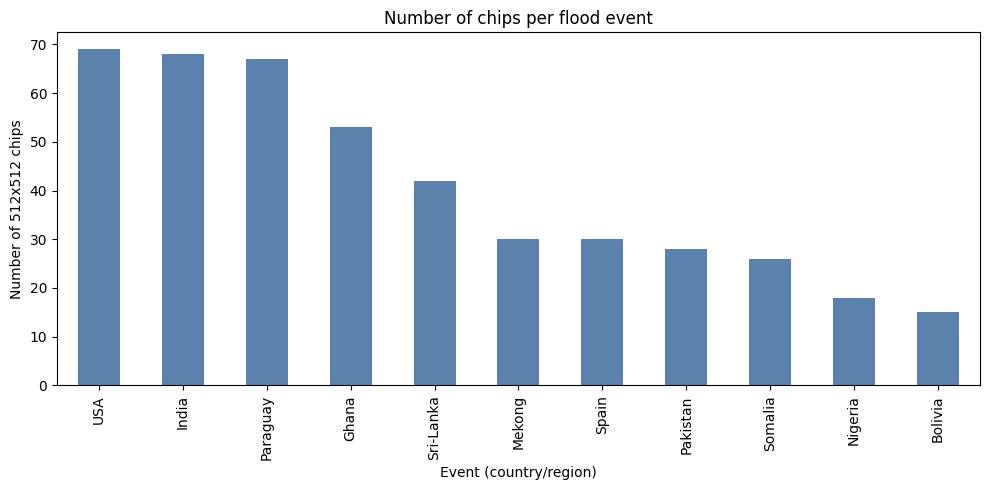

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
event_counts.plot(kind='bar', ax=ax, color=colors[0])
ax.set_title('Number of chips per flood event')
ax.set_xlabel('Event (country/region)')
ax.set_ylabel('Number of 512x512 chips')
plt.tight_layout()
plt.show()

## 2. Visualizing a Sample Chip: SAR image vs Flood Label

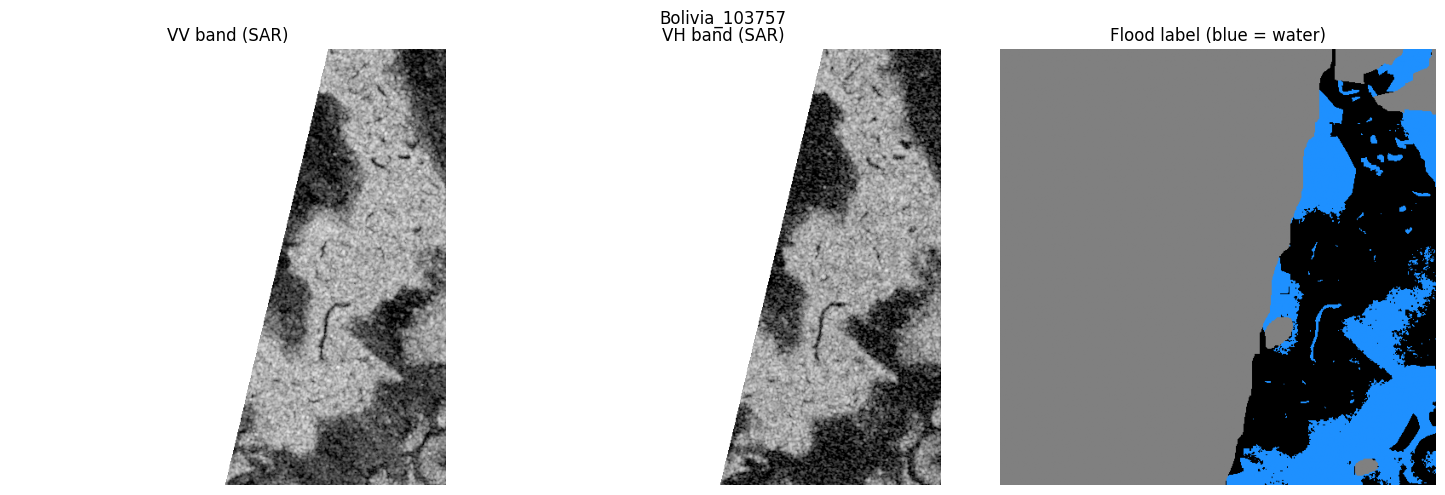

In [4]:
def load_s1(path):
    with rasterio.open(path) as src:
        img = src.read()
    return img

def load_label(path):
    with rasterio.open(path) as src:
        label = src.read(1)
    return label

def show_sample(chip_id):
    s1_path = os.path.join(S1_DIR, f'{chip_id}_S1Hand.tif')
    label_path = os.path.join(LABEL_DIR, f'{chip_id}_LabelHand.tif')

    img = load_s1(s1_path)
    label = load_label(label_path)

    vv = img[0]
    vh = img[1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(vv, cmap='gray', vmin=-25, vmax=0)
    axes[0].set_title('VV band (SAR)')
    axes[0].axis('off')

    axes[1].imshow(vh, cmap='gray', vmin=-30, vmax=-5)
    axes[1].set_title('VH band (SAR)')
    axes[1].axis('off')

    cmap = plt.cm.colors.ListedColormap(['gray', 'black', 'dodgerblue'])
    bounds = [-1.5, -0.5, 0.5, 1.5]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)
    axes[2].imshow(label, cmap=cmap, norm=norm)
    axes[2].set_title('Flood label (blue = water)')
    axes[2].axis('off')

    fig.suptitle(chip_id)
    plt.tight_layout()
    plt.show()

sample_chip_id = os.path.basename(s1_files[0]).replace('_S1Hand.tif', '')
show_sample(sample_chip_id)

## 3. Class Balance: How much of the dataset is actually flooded?

In [5]:
import random
random.seed(42)

label_files = sorted(glob.glob(os.path.join(LABEL_DIR, '*_LabelHand.tif')))
sample_files = random.sample(label_files, min(100, len(label_files)))

counts = {-1: 0, 0: 0, 1: 0}
for f in sample_files:
    label = load_label(f)
    for val in [-1, 0, 1]:
        counts[val] += (label == val).sum()

total = sum(counts.values())
print('Pixel class distribution (sample of 100 chips):')
print(f"  No data (-1): {counts[-1]/total*100:.1f}%")
print(f"  Not water (0): {counts[0]/total*100:.1f}%")
print(f"  Water (1): {counts[1]/total*100:.1f}%")

Pixel class distribution (sample of 100 chips):
  No data (-1): 12.4%
  Not water (0): 78.3%
  Water (1): 9.4%


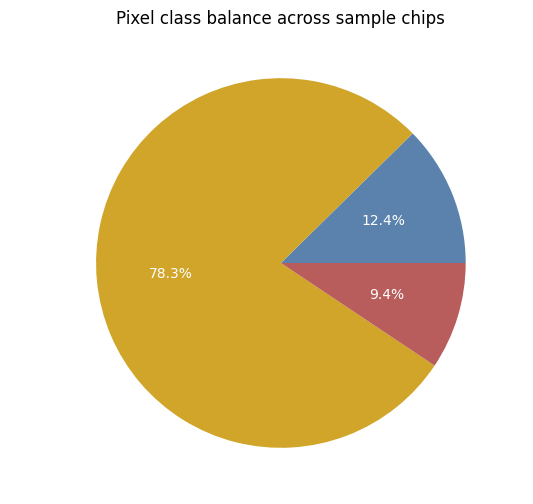

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
labels = ['No data', 'Not water', 'Water']
sizes = [counts[-1], counts[0], counts[1]]
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', textprops={'color': 'white'})
ax.set_title('Pixel class balance across sample chips')
plt.show()

## 4. Key Takeaways

- The dataset contains **446 hand-labeled chips** across **11 distinct flood events** worldwide.
- Water pixels are a **minority class** relative to non-water, this is expected for flood mapping and motivates using **IoU** rather than raw accuracy as the primary evaluation metric.
- SAR VV/VH bands show clear contrast between water (dark/smooth, low backscatter) and land (bright/textured, higher backscatter), which is why SAR is effective for flood detection even through cloud cover — unlike optical imagery.
- 'No data' pixels are masked out (`ignore_index=-1`) during training to avoid penalizing the model on invalid regions.